# 01 — Data Exploration: Bike Itaú GBFS Feed

**Phase 1 — Data Reconnaissance**

**Objective**: Validate data availability, structure, and feasibility of the Bike Itaú (Bike Sampa) GBFS feed for the bike availability forecasting system.

**What we'll do in this notebook**:
1. Fetch and save raw API responses from all GBFS endpoints
2. Document the schema for each endpoint (fields, types, examples)
3. Confirm all required fields exist for the forecasting use case
4. Explore station counts, geographic distribution, and availability patterns
5. Check for null or anomalous values

**Data source**: [GBFS 2.3](https://gbfs.org/) feed from Bike Itaú / Tembici — São Paulo, Brazil  
**Base URL**: `https://saopaulo.publicbikesystem.net/customer/gbfs/v2/`

## 1. Setup

In [1]:
import json
from datetime import datetime, timezone
from pathlib import Path

import httpx
import matplotlib.pyplot as plt
import pandas as pd

SAMPLES_DIR = Path("../data/samples")
SAMPLES_DIR.mkdir(parents=True, exist_ok=True)

BASE_URL = "https://saopaulo.publicbikesystem.net/customer/gbfs/v2"
ENDPOINTS = {
    "gbfs": f"{BASE_URL}/gbfs.json",
    "station_information": f"{BASE_URL}/en/station_information.json",
    "station_status": f"{BASE_URL}/en/station_status.json",
    "vehicle_types": f"{BASE_URL}/en/vehicle_types.json",
}

print("Setup complete ✓")

Setup complete ✓


## 2. Fetch Auto-Discovery Document

The `gbfs.json` file is the entry point for the GBFS feed. It lists all available endpoints, supported languages, and the feed's TTL (time-to-live).

In [2]:
resp = httpx.get(ENDPOINTS["gbfs"], timeout=15)
resp.raise_for_status()
gbfs_data = resp.json()

print(f"GBFS version: {gbfs_data.get('version', 'N/A')}")
print(f"TTL: {gbfs_data.get('data', {}).get('ttl', gbfs_data.get('ttl', 'N/A'))} seconds")
print(f"\nAvailable languages: {list(gbfs_data.get('data', {}).keys())}")

# List all feeds for the English language
en_feeds = gbfs_data["data"].get("en", gbfs_data["data"].get("pt", {}).get("feeds", []))
if isinstance(en_feeds, dict):
    en_feeds = en_feeds.get("feeds", [])

print(f"\nAvailable feeds ({len(en_feeds)}):")
for feed in en_feeds:
    print(f"  - {feed['name']}: {feed['url']}")

GBFS version: 2.3
TTL: 30 seconds

Available languages: ['pt', 'en', 'fr', 'es']

Available feeds (8):
  - geofencing_zones: https://saopaulo.publicbikesystem.net/customer/gbfs/v2/en/geofencing_zones
  - gbfs_versions: https://saopaulo.publicbikesystem.net/customer/gbfs/v2/gbfs_versions
  - vehicle_types: https://saopaulo.publicbikesystem.net/customer/gbfs/v2/en/vehicle_types
  - station_information: https://saopaulo.publicbikesystem.net/customer/gbfs/v2/en/station_information
  - station_status: https://saopaulo.publicbikesystem.net/customer/gbfs/v2/en/station_status
  - system_regions: https://saopaulo.publicbikesystem.net/customer/gbfs/v2/en/system_regions
  - system_information: https://saopaulo.publicbikesystem.net/customer/gbfs/v2/en/system_information
  - system_pricing_plans: https://saopaulo.publicbikesystem.net/customer/gbfs/v2/en/system_pricing_plans


## 3. Fetch and Save All Samples

Fetch all 4 endpoints and save the raw JSON responses to `data/samples/` for reproducibility.

In [3]:
raw_data = {}

for name, url in ENDPOINTS.items():
    print(f"Fetching {name}...", end=" ")
    resp = httpx.get(url, timeout=15)
    resp.raise_for_status()
    data = resp.json()
    raw_data[name] = data

    # Save to data/samples/
    filepath = SAMPLES_DIR / f"{name}.json"
    with open(filepath, "w", encoding="utf-8") as f:
        json.dump(data, f, indent=2, ensure_ascii=False)
    print(f"saved → {filepath}")

print(f"\nAll {len(raw_data)} samples saved to {SAMPLES_DIR}/")

Fetching gbfs... saved → ..\data\samples\gbfs.json
Fetching station_information... saved → ..\data\samples\station_information.json
Fetching station_status... saved → ..\data\samples\station_status.json
Fetching vehicle_types... saved → ..\data\samples\vehicle_types.json

All 4 samples saved to ..\data\samples/


## 4. Station Information — Schema

The `station_information` endpoint provides static data about each station: location, name, capacity, and rental methods.

In [4]:
stations_info = raw_data["station_information"]["data"]["stations"]
df_info = pd.DataFrame(stations_info)

print(f"Total stations: {len(df_info)}")
print(f"Shape: {df_info.shape}")
print(f"\nColumns ({len(df_info.columns)}):")
print(df_info.dtypes.to_string())
print(f"\nSample record:")
df_info.head(3)

Total stations: 240
Shape: (240, 21)

Columns (21):
station_id                 object
name                       object
physical_configuration     object
lat                       float64
lon                       float64
altitude                  float64
address                    object
capacity                    int64
is_charging_station          bool
geofenced_capacity          int64
rental_methods             object
is_virtual_station           bool
groups                     object
obcn                       object
short_name                 object
nearby_distance           float64
_bluetooth_id              object
_ride_code_support           bool
rental_uris                object
post_code                  object
cross_street               object

Sample record:


,station_id,name,physical_configuration,lat,lon,altitude,address,capacity,is_charging_station,geofenced_capacity,...,is_virtual_station,groups,obcn,short_name,nearby_distance,_bluetooth_id,_ride_code_support,rental_uris,post_code,cross_street
0,1,1 - Largo da Batata,REGULAR,-23.566831,-46.693741,NaN,"Av. Brigadeiro Faria Lima, esquina R. Teodoro ...",83,False,0,...,False,[G3 - Pinheiros/Jardins],1,1,1000.0,,True,{},NaN,NaN
1,3,3 - CPTM Pinheiros,VAULT,-23.566478,-46.701258,NaN,"R. Gilberto Sabino, 138/ ao lado do ponto de ô...",15,False,0,...,False,[G3 - Pinheiros/Jardins],3,3,1000.0,,True,{},03164200,NaN
2,4,4 - Rua Diogo Moreira,REGULAR,-23.569145,-46.692003,NaN,"Av. Brigadeiro Faria Lima, na altura do número...",23,False,0,...,False,[G3 - Pinheiros/Jardins],4,4,1000.0,,True,{},03164200,NaN


## 5. Station Status — Schema

The `station_status` endpoint provides real-time data: bike availability, dock availability, and operational status. This is the **primary endpoint** for the forecasting model.

In [5]:
stations_status = raw_data["station_status"]["data"]["stations"]
df_status = pd.DataFrame(stations_status)

print(f"Total station records: {len(df_status)}")
print(f"Shape: {df_status.shape}")
print(f"TTL: {raw_data['station_status'].get('ttl', 'N/A')} seconds")
print(f"Last updated: {datetime.fromtimestamp(raw_data['station_status']['last_updated'], tz=timezone.utc)}")
print(f"\nColumns ({len(df_status.columns)}):")
print(df_status.dtypes.to_string())
print(f"\nSample record:")
df_status.head(3)

Total station records: 240
Shape: (240, 14)
TTL: 30 seconds
Last updated: 2026-03-25 19:32:16+00:00

Columns (14):
station_id                 object
num_bikes_available         int64
num_bikes_disabled          int64
is_charging_station          bool
status                     object
traffic                    object
num_docks_available         int64
num_docks_disabled          int64
last_reported               int64
is_installed                 bool
is_renting                   bool
is_returning                 bool
vehicle_docks_available    object
vehicle_types_available    object

Sample record:


,station_id,num_bikes_available,num_bikes_disabled,is_charging_station,status,traffic,num_docks_available,num_docks_disabled,last_reported,is_installed,is_renting,is_returning,vehicle_docks_available,vehicle_types_available
0,1,20,0,False,IN_SERVICE,None,63,0,1774467106,True,True,True,"[{'vehicle_type_ids': ['FIT', 'ICONIC', 'BOOST...","[{'vehicle_type_id': 'FIT', 'count': 19}, {'ve..."
1,3,7,0,False,IN_SERVICE,None,8,0,1774467068,True,True,True,"[{'vehicle_type_ids': ['FIT', 'ICONIC', 'BOOST...","[{'vehicle_type_id': 'FIT', 'count': 7}, {'veh..."
2,4,1,0,False,IN_SERVICE,None,22,0,1774466966,True,True,True,"[{'vehicle_type_ids': ['FIT', 'ICONIC', 'BOOST...","[{'vehicle_type_id': 'FIT', 'count': 1}, {'veh..."


## 6. Vehicle Types

The `vehicle_types` endpoint describes the different vehicle categories available in the system (bikes, e-bikes, scooters).

In [6]:
vehicle_types = raw_data["vehicle_types"]["data"]["vehicle_types"]
df_vehicles = pd.DataFrame(vehicle_types)

print(f"Total vehicle types: {len(df_vehicles)}")
print(f"\nVehicle categories:")
df_vehicles[["vehicle_type_id", "name", "form_factor", "propulsion_type"]].to_string(index=False)
df_vehicles[["vehicle_type_id", "name", "form_factor", "propulsion_type"]]

Total vehicle types: 17

Vehicle categories:


,vehicle_type_id,name,form_factor,propulsion_type
0,ICONIC,ICONIC,bicycle,human
1,FIT,FIT,bicycle,human
2,BOOST,BOOST,bicycle,electric_assist
3,EFIT,EFIT,bicycle,electric_assist
4,INMOTION,INMOTION,scooter_standing,electric
5,INMOTION_MEC,INMOTION_MEC,scooter_standing,electric_assist
6,INMOTION_ELECTRIC,INMOTION_ELECTRIC,scooter_standing,electric_assist
7,PEDALLA,PEDALLA,bicycle,electric_assist
8,EFIT LARANJA,EFIT LARANJA,bicycle,electric_assist
9,EFIT LARANJINHA,EFIT LARANJINHA,bicycle,electric_assist


## 7. Schema Documentation

Summary of fields across all endpoints, marking which are **required** for the forecasting model and which are **bonus** fields.

### Required Fields (for forecasting)
| Field | Endpoint | Type | Description |
|-------|----------|------|-------------|
| `station_id` | station_status | string | Unique station identifier |
| `num_bikes_available` | station_status | int | **Target variable** — bikes available now |
| `num_docks_available` | station_status | int | Empty docks available |
| `last_reported` | station_status | int (unix timestamp) | When station last reported data |

### Bonus Fields (enrichment)
| Field | Endpoint | Type | Description |
|-------|----------|------|-------------|
| `vehicle_types_available` | station_status | array | Breakdown by vehicle type |
| `is_renting` | station_status | bool | Station accepting rentals |
| `is_returning` | station_status | bool | Station accepting returns |
| `capacity` | station_information | int | Total dock capacity |
| `lat` / `lon` | station_information | float | Geographic coordinates |
| `name` | station_information | string | Human-readable station name |

### Data Refresh Rate
- **station_status TTL**: ~22–30 seconds
- **station_information TTL**: ~30 seconds (static data, rarely changes)

## 8. Station Counts

In [7]:
total_stations = len(df_status)
active_renting = df_status["is_renting"].sum()
active_returning = df_status["is_returning"].sum()
installed = df_status["is_installed"].sum() if "is_installed" in df_status.columns else "N/A"

total_bikes = df_status["num_bikes_available"].sum()
total_docks = df_status["num_docks_available"].sum()

print("=" * 50)
print("STATION SUMMARY")
print("=" * 50)
print(f"Total stations:          {total_stations}")
print(f"Installed:               {installed}")
print(f"Active (renting):        {active_renting}")
print(f"Active (returning):      {active_returning}")
print(f"Inactive (not renting):  {total_stations - active_renting}")
print(f"")
print(f"Total bikes available:   {total_bikes}")
print(f"Total docks available:   {total_docks}")
print(f"System-wide occupancy:   {total_bikes / (total_bikes + total_docks) * 100:.1f}%")

STATION SUMMARY
Total stations:          240
Installed:               240
Active (renting):        240
Active (returning):      240
Inactive (not renting):  0

Total bikes available:   1266
Total docks available:   2822
System-wide occupancy:   31.0%


## 9. Geographic Distribution

Scatter plot of all stations by latitude/longitude, colored by operational status (renting vs. not renting).

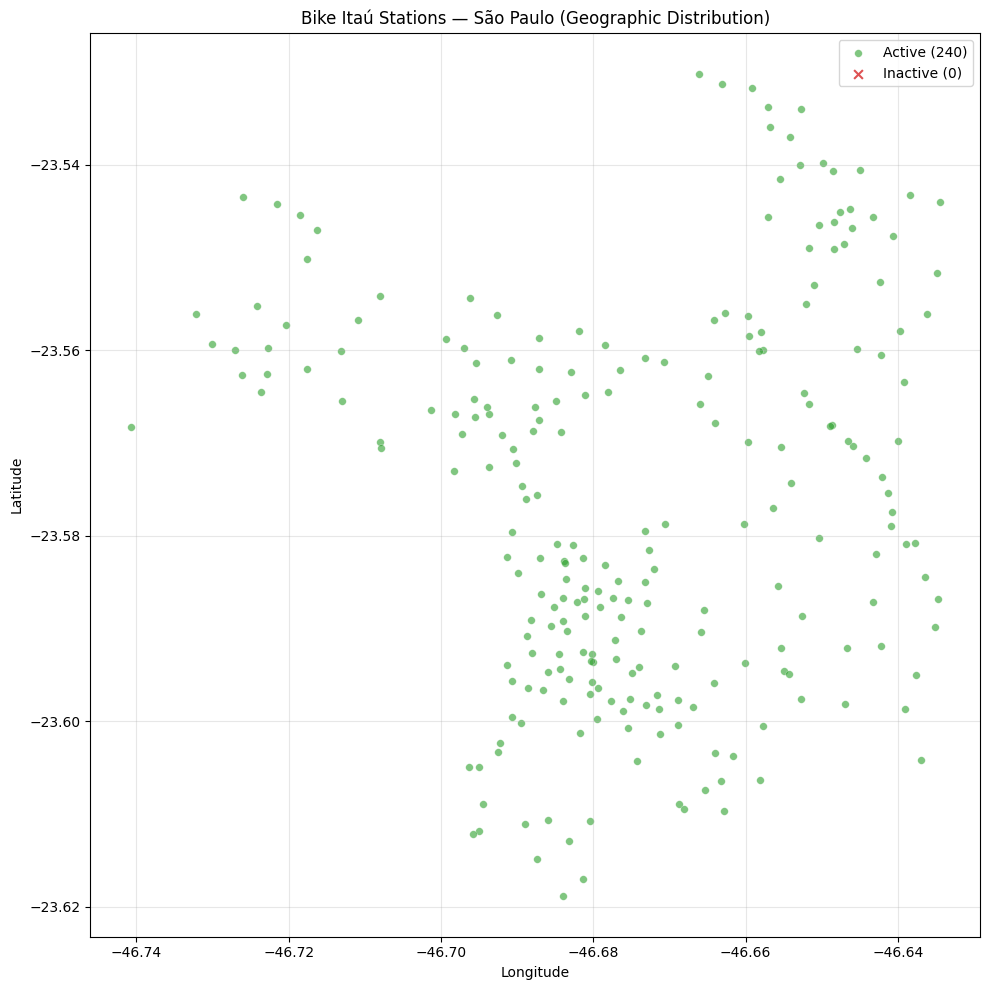

In [8]:
# Merge station info (lat/lon) with status (is_renting)
df_geo = df_info[["station_id", "lat", "lon", "name", "capacity"]].merge(
    df_status[["station_id", "is_renting", "num_bikes_available"]],
    on="station_id",
    how="inner",
)

fig, ax = plt.subplots(figsize=(10, 10))

active = df_geo[df_geo["is_renting"] == True]
inactive = df_geo[df_geo["is_renting"] == False]

ax.scatter(
    active["lon"], active["lat"],
    c="tab:green", alpha=0.6, s=30, label=f"Active ({len(active)})", edgecolors="white", linewidths=0.3,
)
ax.scatter(
    inactive["lon"], inactive["lat"],
    c="tab:red", alpha=0.8, s=40, marker="x", label=f"Inactive ({len(inactive)})",
)

ax.set_xlabel("Longitude")
ax.set_ylabel("Latitude")
ax.set_title("Bike Itaú Stations — São Paulo (Geographic Distribution)")
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## 10. Availability Distribution

Histogram of `num_bikes_available` across all stations at the time of this snapshot.

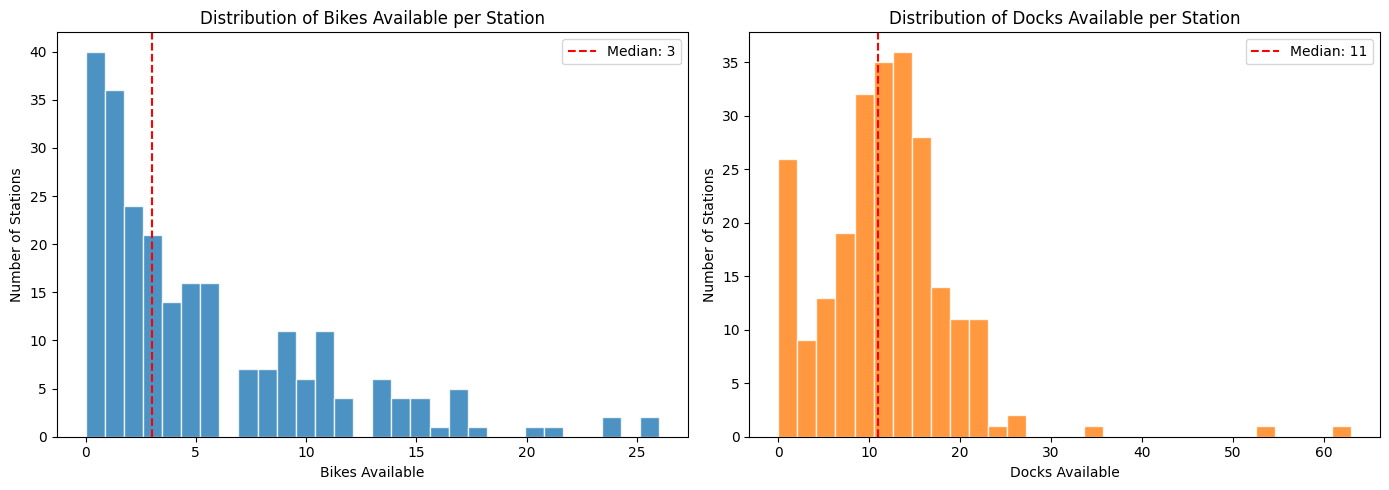


Bikes available — descriptive statistics:
count    240.000000
mean       5.275000
std        5.450366
min        0.000000
25%        1.000000
50%        3.000000
75%        8.000000
max       26.000000


In [9]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Histogram — bikes available
axes[0].hist(df_status["num_bikes_available"], bins=30, color="tab:blue", edgecolor="white", alpha=0.8)
axes[0].set_xlabel("Bikes Available")
axes[0].set_ylabel("Number of Stations")
axes[0].set_title("Distribution of Bikes Available per Station")
axes[0].axvline(df_status["num_bikes_available"].median(), color="red", linestyle="--", label=f"Median: {df_status['num_bikes_available'].median():.0f}")
axes[0].legend()

# Histogram — docks available
axes[1].hist(df_status["num_docks_available"], bins=30, color="tab:orange", edgecolor="white", alpha=0.8)
axes[1].set_xlabel("Docks Available")
axes[1].set_ylabel("Number of Stations")
axes[1].set_title("Distribution of Docks Available per Station")
axes[1].axvline(df_status["num_docks_available"].median(), color="red", linestyle="--", label=f"Median: {df_status['num_docks_available'].median():.0f}")
axes[1].legend()

plt.tight_layout()
plt.show()

print(f"\nBikes available — descriptive statistics:")
print(df_status["num_bikes_available"].describe().to_string())

## 11. Null and Anomaly Check

Verify data quality: check for null values in critical fields and look for anomalous values (negative counts, future timestamps, etc.).

In [10]:
print("=" * 50)
print("NULL CHECK — station_status")
print("=" * 50)

required_fields = ["station_id", "num_bikes_available", "num_docks_available", "last_reported"]
bonus_fields = ["is_renting", "is_returning", "vehicle_types_available"]

for field in required_fields + bonus_fields:
    if field in df_status.columns:
        nulls = df_status[field].isnull().sum()
        tag = "REQUIRED" if field in required_fields else "BONUS"
        status = "OK" if nulls == 0 else f"WARNING: {nulls} nulls"
        print(f"  [{tag}] {field:30s} → {status}")
    else:
        print(f"  [MISSING] {field:30s} → NOT FOUND IN RESPONSE")

print(f"\n{'=' * 50}")
print("NULL CHECK — station_information")
print("=" * 50)

info_fields = ["station_id", "lat", "lon", "capacity", "name"]
for field in info_fields:
    if field in df_info.columns:
        nulls = df_info[field].isnull().sum()
        status = "OK" if nulls == 0 else f"WARNING: {nulls} nulls"
        print(f"  {field:30s} → {status}")

print(f"\n{'=' * 50}")
print("ANOMALY CHECK")
print("=" * 50)

# Negative values
neg_bikes = (df_status["num_bikes_available"] < 0).sum()
neg_docks = (df_status["num_docks_available"] < 0).sum()
print(f"  Negative num_bikes_available:  {neg_bikes} {'OK' if neg_bikes == 0 else 'ANOMALY'}")
print(f"  Negative num_docks_available:  {neg_docks} {'OK' if neg_docks == 0 else 'ANOMALY'}")

# Future timestamps
now_ts = datetime.now(tz=timezone.utc).timestamp()
future_reports = (df_status["last_reported"] > now_ts + 300).sum()  # 5 min tolerance
print(f"  Future last_reported (>5min):  {future_reports} {'OK' if future_reports == 0 else 'ANOMALY'}")

# Stations with 0 capacity
if "capacity" in df_info.columns:
    zero_cap = (df_info["capacity"] == 0).sum()
    print(f"  Stations with 0 capacity:      {zero_cap} {'OK' if zero_cap == 0 else 'NOTE'}")

# Orphaned station_ids (status without info)
status_ids = set(df_status["station_id"])
info_ids = set(df_info["station_id"])
orphans = status_ids - info_ids
print(f"  Orphan station_ids (no info):  {len(orphans)} {'OK' if len(orphans) == 0 else 'NOTE: ' + str(orphans)}")

NULL CHECK — station_status
  [REQUIRED] station_id                     → OK
  [REQUIRED] num_bikes_available            → OK
  [REQUIRED] num_docks_available            → OK
  [REQUIRED] last_reported                  → OK
  [BONUS] is_renting                     → OK
  [BONUS] is_returning                   → OK
  [BONUS] vehicle_types_available        → OK

NULL CHECK — station_information
  station_id                     → OK
  lat                            → OK
  lon                            → OK
  capacity                       → OK
  name                           → OK

ANOMALY CHECK
  Negative num_bikes_available:  0 OK
  Negative num_docks_available:  0 OK
  Future last_reported (>5min):  0 OK
  Stations with 0 capacity:      0 OK
  Orphan station_ids (no info):  0 OK


## 12. Conclusion

### Findings

1. **Data availability**: All 4 GBFS endpoints are accessible, public, and return well-structured JSON
2. **Required fields**: All required fields (`station_id`, `num_bikes_available`, `num_docks_available`, `last_reported`) are present and non-null
3. **Bonus fields**: All bonus fields (`vehicle_types_available`, `is_renting`, `is_returning`, `capacity`) are available for enrichment
4. **Station coverage**: ~240 stations across São Paulo with geographic coordinates for spatial analysis
5. **Vehicle diversity**: 17 vehicle types including bikes, e-bikes, and scooters
6. **Data refresh**: TTL of ~22–30 seconds — suitable for 5-minute ingestion intervals
7. **Data quality**: No nulls in critical fields, no negative counts, no future timestamps

### Verdict

**The Bike Itaú GBFS feed is fully suitable for the forecasting use case.** All required data is available, well-structured, and of sufficient quality to proceed to Phase 2 (Data Ingestion Pipeline).